# Notebook 2: Adstock & Saturation Transformations from Scratch

**Marketing Science Bootcamp -- Week 2 Offline**

---

## Learning Objectives

By the end of this notebook you will be able to:

1. **Understand geometric adstock** and why media effects carry over across time periods.
2. **Understand Hill saturation** and why diminishing returns are a fundamental feature of advertising.
3. **Implement both transformations from scratch** in Python (no library black boxes).
4. **Visualize the effect of each parameter** so you can build intuition for tuning MMMs.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Add project root so we can import shared utilities
sys.path.insert(0, "../..")

# Plotting defaults
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Setup complete.")

Setup complete.


---

## Section 1: Geometric Adstock

### The Idea

When a consumer sees a TV ad today, they do not forget it tomorrow. The **adstock** transformation captures this *carry-over* (or *decay*) effect.

### The Formula

For a raw media series $x_t$ and a decay parameter $\theta \in [0, 1]$:

$$
x_{\text{decayed}}[t] = x[t] + \theta \cdot x_{\text{decayed}}[t-1]
$$

- When $\theta = 0$: no carry-over at all -- only the current period's spend matters.
- When $\theta \to 1$: effects persist almost indefinitely.

This is a simple **geometric (exponential) decay**: each previous period's contribution is multiplied by $\theta$ one more time.

In [18]:
def adstock_geometric(x, theta):
    """Apply geometric (carry-over) adstock transformation.

    Parameters
    ----------
    x : array-like
        Input media series (spend, GRP, impressions, etc.).
    theta : float
        Decay rate in [0, 1]. Higher = slower decay.

    Returns
    -------
    np.ndarray -- adstocked series.
    """
    x = np.asarray(x, dtype=float)
    x_decayed = np.zeros_like(x)
    x_decayed[0] = x[0]

    for i in range(1, len(x)):
        x_decayed[i] = x[i] + theta * x_decayed[i - 1]

    return x_decayed


# Quick sanity check
test = adstock_geometric([100, 0, 0, 0, 0], theta=0.5)
print("Input : [100, 0, 0, 0, 0]")
print("Output:", test)
print("Expected: [100, 50, 25, 12.5, 6.25]")

Input : [100, 0, 0, 0, 0]
Output: [100.    50.    25.    12.5    6.25]
Expected: [100, 50, 25, 12.5, 6.25]


In [19]:
# Create synthetic impulse data: single spike of 100 at t=5, zeros elsewhere
n_periods = 30
impulse = np.zeros(n_periods)
impulse[5] = 100  # single media burst at period 5

print(f"Impulse data: {n_periods} periods, spike of 100 at t=5")
print(impulse)

Impulse data: 30 periods, spike of 100 at t=5
[  0.   0.   0.   0.   0. 100.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.]


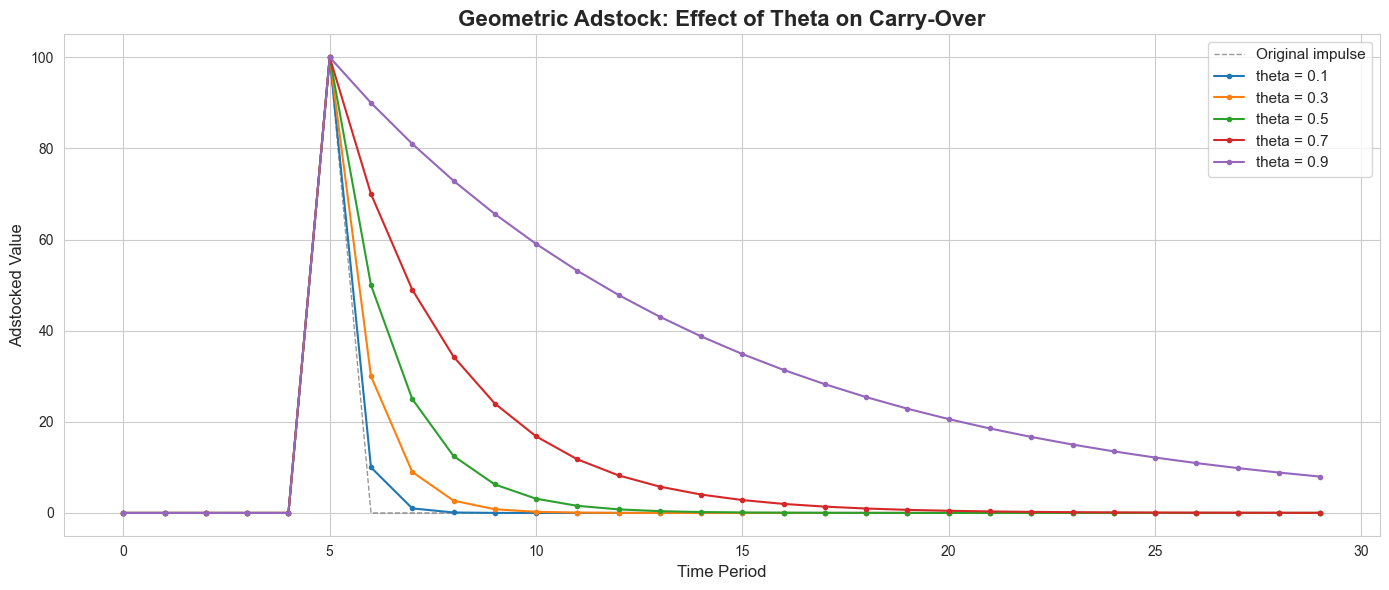

In [20]:
# Visualize decay for different theta values
thetas = [0.1, 0.3, 0.5, 0.7, 0.9]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(impulse, "k--", alpha=0.4, label="Original impulse", linewidth=1)

for theta in thetas:
    decayed = adstock_geometric(impulse, theta)
    ax.plot(decayed, marker=".", linewidth=1.5, label=f"theta = {theta}")

ax.set_title("Geometric Adstock: Effect of Theta on Carry-Over", fontsize=16, fontweight="bold")
ax.set_xlabel("Time Period", fontsize=12)
ax.set_ylabel("Adstocked Value", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Reflection Questions

- **What happens as theta increases?** The decay becomes slower, meaning past spend continues to influence the present for longer.
- **Which channel types would have high vs. low theta?**
  - **High theta (slow decay):** TV, brand campaigns, outdoor -- these build long-lasting memory traces.
  - **Low theta (fast decay):** Paid search, performance display -- intent-driven, effects are immediate and short-lived.

---

## Section 2: Apply Adstock to Workshop Data

In [21]:
# Load the workshop dataset
data = pd.read_excel("../../data/MMM_Workshop_Data.xlsx", sheet_name="Data")
print(f"Data loaded: {data.shape[0]} rows x {data.shape[1]} columns")
data.head(3)

Data loaded: 36 rows x 54 columns


,Month,Sales_Revenue_Total,Sales_Volume_Total,Average_Price_Total,Market_Share_Brand_M_Total,Sales_Revenue_Category1,Sales_Volume_(Units_sold)_Category1,Average_Price_Category1,Sales_Revenue_Channel1,Sales_Volume_(Units_sold)_Channel1,...,Online_Video_Impressions,Meta_Agg_Impressions,YouTube_Views,Paid_Search_Clicks,META_Clicks,Online_Video_Views,Influencer_Marketing_Spends,Brand_B_ATL_Spends,Brand_PH_ATL_Spends,Brand_P_ATL_Spends
0,2021-01-01,1.014326e+06,383756,2.643154,NaN,6581.46,2203,2.987499,93772.80069,29367,...,0,12065097,0,2068,27850,0,0.0,105967.3037,1974.074442,136852.2889
1,2021-02-01,9.258418e+05,367705,2.517893,NaN,8064.66,2624,3.073422,90543.94969,28953,...,0,6295714,0,2129,9306,0,0.0,108336.7238,0.000000,116321.2626
2,2021-03-01,1.097930e+06,442299,2.482324,NaN,10275.35,3390,3.031077,98835.76296,31822,...,0,28820862,0,3762,65079,0,0.0,191465.3549,0.000000,171548.4949


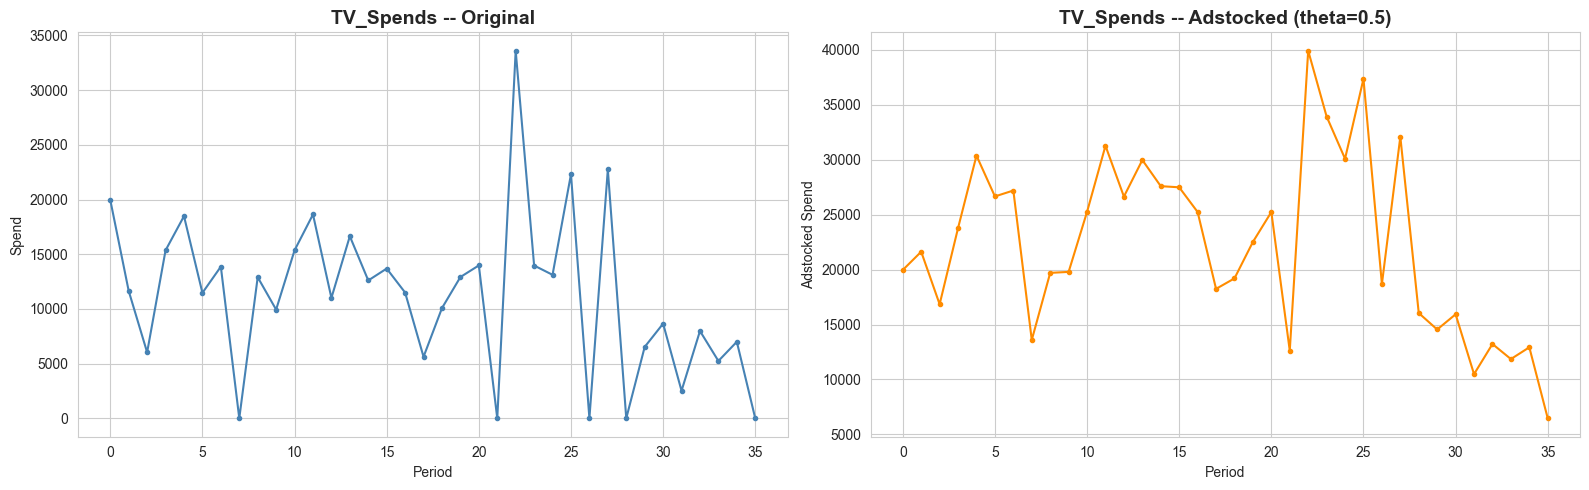

Original total: 405,415
Adstocked total: 804,366
Inflation ratio: 1.98x


In [22]:
# Apply adstock to TV_Spends with theta = 0.5 (moderate carry-over)
tv_original = data["TV_Spends"].values
tv_adstocked = adstock_geometric(tv_original, theta=0.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(tv_original, marker=".", color="steelblue", linewidth=1.5)
axes[0].set_title("TV_Spends -- Original", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Spend")

axes[1].plot(tv_adstocked, marker=".", color="darkorange", linewidth=1.5)
axes[1].set_title("TV_Spends -- Adstocked (theta=0.5)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Adstocked Spend")

plt.tight_layout()
plt.show()

print(f"Original total: {tv_original.sum():,.0f}")
print(f"Adstocked total: {tv_adstocked.sum():,.0f}")
print(f"Inflation ratio: {tv_adstocked.sum() / tv_original.sum():.2f}x")

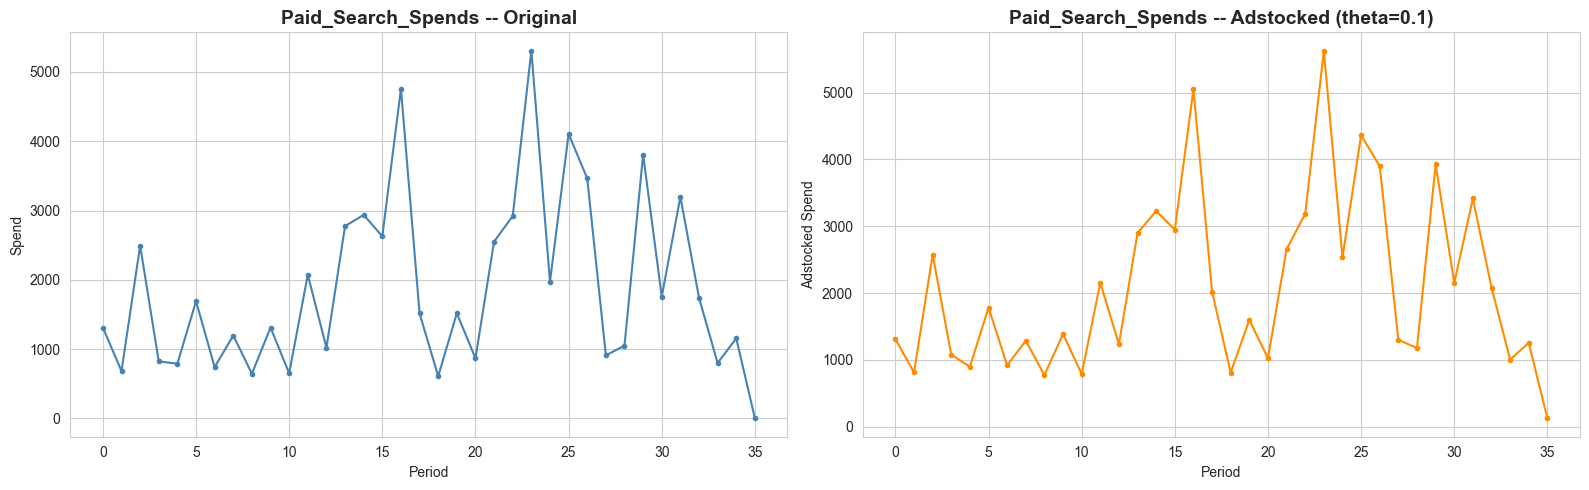

Original total: 67,765
Adstocked total: 75,281
Inflation ratio: 1.11x

Notice: with theta=0.1, the shape barely changes -- paid search is already very 'present-focused'.


In [23]:
# Apply adstock to Paid_Search_Spends with theta = 0.1 (fast decay -- digital channel)
ps_original = data["Paid_Search_Spends"].values
ps_adstocked = adstock_geometric(ps_original, theta=0.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ps_original, marker=".", color="steelblue", linewidth=1.5)
axes[0].set_title("Paid_Search_Spends -- Original", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Spend")

axes[1].plot(ps_adstocked, marker=".", color="darkorange", linewidth=1.5)
axes[1].set_title("Paid_Search_Spends -- Adstocked (theta=0.1)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Adstocked Spend")

plt.tight_layout()
plt.show()

print(f"Original total: {ps_original.sum():,.0f}")
print(f"Adstocked total: {ps_adstocked.sum():,.0f}")
print(f"Inflation ratio: {ps_adstocked.sum() / ps_original.sum():.2f}x")
print("\nNotice: with theta=0.1, the shape barely changes -- paid search is already very 'present-focused'.")

---

## Section 3: Hill Saturation

### The Idea

Doubling your TV budget does **not** double sales. At some point you hit **diminishing returns** -- the audience is saturated. The **Hill function** models this S-shaped (or concave) relationship.

### The Formula

$$
\text{saturated}(x) = \frac{x^{\alpha}}{x^{\alpha} + \text{inflexion}^{\alpha}}
$$

where:

$$
\text{inflexion} = \min(x) \cdot (1 - \gamma) + \max(x) \cdot \gamma
$$

- **alpha ($\alpha$):** Controls the **steepness** of the curve. Higher alpha = sharper S-shape.
- **gamma ($\gamma$):** Controls the **inflection point** -- where the curve transitions from steep to flat. It is a fraction in $[0, 1]$ that positions the inflection between the min and max of the series.

In [24]:
def saturation_hill(x, alpha, gamma):
    """Hill (S-curve) saturation transformation.

    Parameters
    ----------
    x : array-like
        Input series (typically adstocked spend).
    alpha : float
        Shape parameter controlling curve steepness.
    gamma : float
        Parameter in [0, 1] controlling inflection point position
        between min(x) and max(x).

    Returns
    -------
    np.ndarray -- saturated series in [0, 1].
    """
    x = np.asarray(x, dtype=float)
    inflexion = np.min(x) * (1 - gamma) + np.max(x) * gamma
    return x**alpha / (x**alpha + inflexion**alpha)


# Quick sanity check
test_x = np.array([0, 25000, 50000, 75000, 100000])
test_sat = saturation_hill(test_x, alpha=2.0, gamma=0.5)
print("Input :", test_x)
print("Output:", np.round(test_sat, 4))

Input : [     0  25000  50000  75000 100000]
Output: [0.     0.2    0.5    0.6923 0.8   ]


In [25]:
# Simulated spend range
spend_range = np.linspace(1, 100000, 500)  # start from 1 to avoid 0^alpha issues

print(f"Spend range: {spend_range[0]:,.0f} to {spend_range[-1]:,.0f} ({len(spend_range)} points)")

Spend range: 1 to 100,000 (500 points)


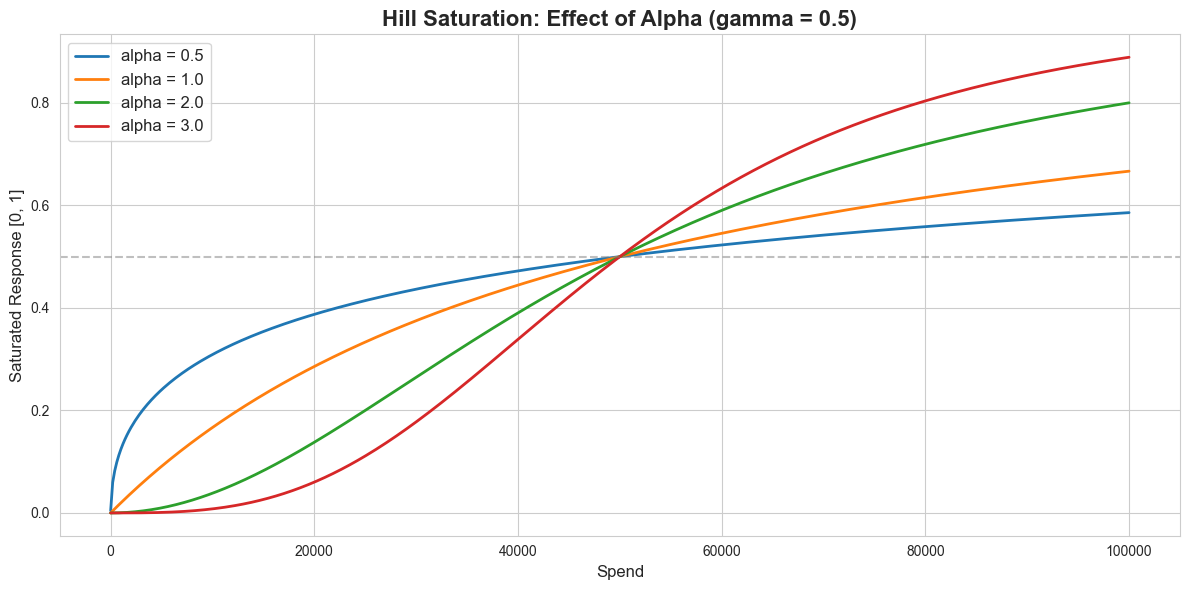

In [26]:
# Plot Hill curves for different ALPHA values (gamma fixed at 0.5)
alphas = [0.5, 1.0, 2.0, 3.0]
gamma_fixed = 0.5

fig, ax = plt.subplots(figsize=(12, 6))

for alpha in alphas:
    saturated = saturation_hill(spend_range, alpha=alpha, gamma=gamma_fixed)
    ax.plot(spend_range, saturated, linewidth=2, label=f"alpha = {alpha}")

ax.set_title(f"Hill Saturation: Effect of Alpha (gamma = {gamma_fixed})", fontsize=16, fontweight="bold")
ax.set_xlabel("Spend", fontsize=12)
ax.set_ylabel("Saturated Response [0, 1]", fontsize=12)
ax.legend(fontsize=12)
ax.axhline(0.5, color="gray", ls="--", alpha=0.5, label="50% response")
plt.tight_layout()
plt.show()

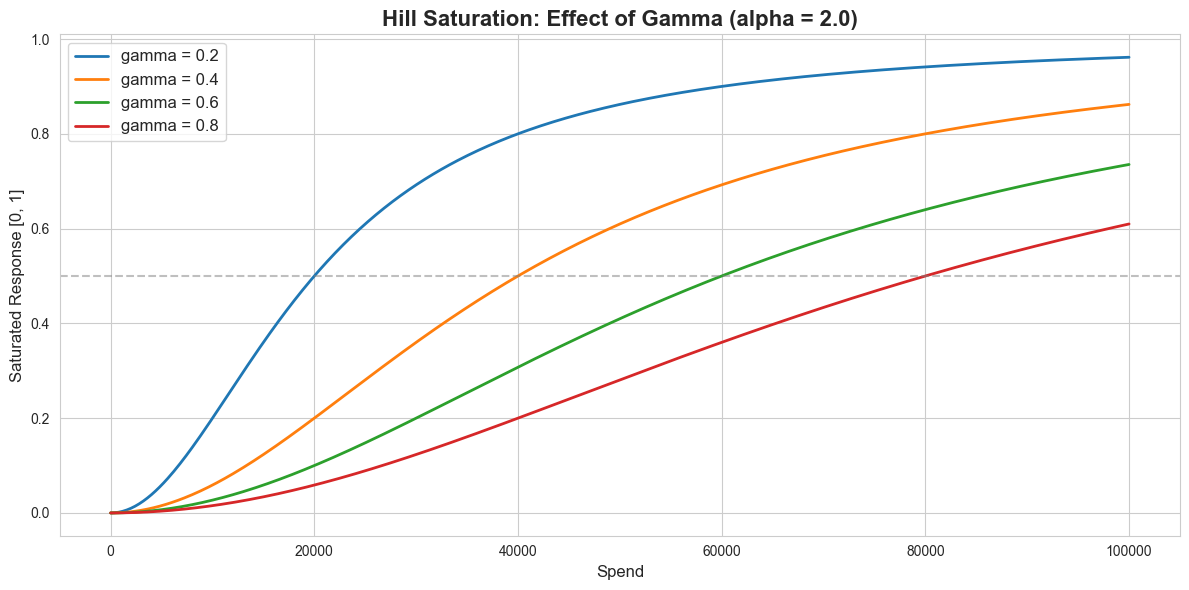

In [27]:
# Plot Hill curves for different GAMMA values (alpha fixed at 2.0)
gammas = [0.2, 0.4, 0.6, 0.8]
alpha_fixed = 2.0

fig, ax = plt.subplots(figsize=(12, 6))

for gamma in gammas:
    saturated = saturation_hill(spend_range, alpha=alpha_fixed, gamma=gamma)
    ax.plot(spend_range, saturated, linewidth=2, label=f"gamma = {gamma}")

ax.set_title(f"Hill Saturation: Effect of Gamma (alpha = {alpha_fixed})", fontsize=16, fontweight="bold")
ax.set_xlabel("Spend", fontsize=12)
ax.set_ylabel("Saturated Response [0, 1]", fontsize=12)
ax.legend(fontsize=12)
ax.axhline(0.5, color="gray", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Parameter Interpretation

- **Alpha** controls the **steepness** of the curve:
  - `alpha < 1`: concave from the start (logarithmic shape -- diminishing returns immediately)
  - `alpha = 1`: a simple Hill function (smooth transition)
  - `alpha > 1`: S-shaped curve (initial increasing returns, then diminishing)

- **Gamma** controls the **inflection point** (where the curve bends):
  - Low gamma (e.g., 0.2): saturation kicks in early -- the channel is "cheap" to saturate
  - High gamma (e.g., 0.8): it takes a lot of spend before diminishing returns appear

---

## Section 4: Combined Pipeline -- Adstock then Saturation

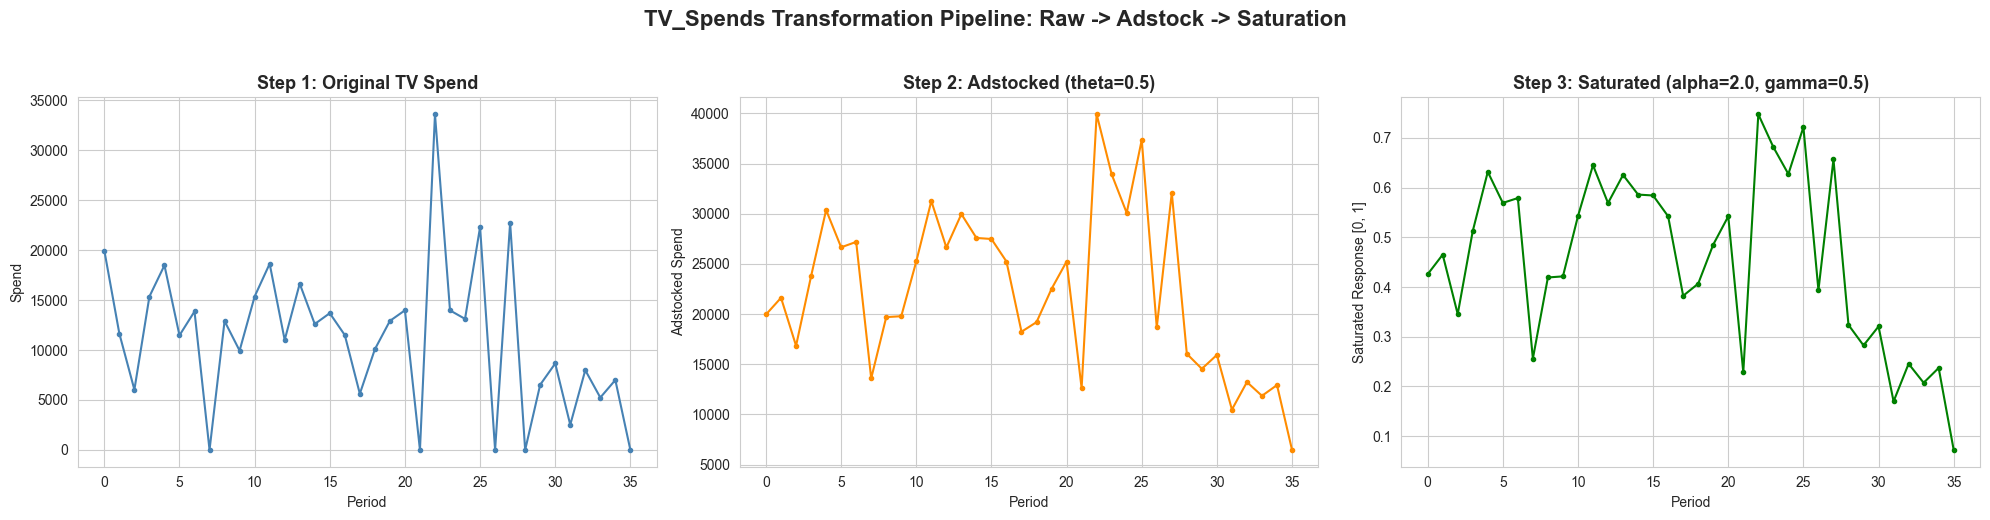

In [28]:
# Full pipeline: original -> adstocked -> saturated for TV_Spends
tv_raw = data["TV_Spends"].values
tv_adstocked = adstock_geometric(tv_raw, theta=0.5)
tv_saturated = saturation_hill(tv_adstocked, alpha=2.0, gamma=0.5)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Subplot 1: Original
axes[0].plot(tv_raw, marker=".", color="steelblue", linewidth=1.5)
axes[0].set_title("Step 1: Original TV Spend", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Spend")

# Subplot 2: Adstocked
axes[1].plot(tv_adstocked, marker=".", color="darkorange", linewidth=1.5)
axes[1].set_title("Step 2: Adstocked (theta=0.5)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Adstocked Spend")

# Subplot 3: Saturated
axes[2].plot(tv_saturated, marker=".", color="green", linewidth=1.5)
axes[2].set_title("Step 3: Saturated (alpha=2.0, gamma=0.5)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Period")
axes[2].set_ylabel("Saturated Response [0, 1]")

fig.suptitle("TV_Spends Transformation Pipeline: Raw -> Adstock -> Saturation",
             fontsize=16, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

---

## Exercise: Find Good Parameters for Each Channel

Your task is to **experiment** with adstock and saturation parameters for three different channel types:

| Channel | Expected Decay | Reasoning |
|---------|---------------|----------|
| **TV_Spends** | Slow (theta = 0.4--0.8) | Brand building, long memory |
| **Paid_Search_Spends** | Fast (theta = 0.0--0.2) | Intent-driven, immediate response |
| **Programmatic_Display_Spends** | Moderate (theta = 0.1--0.4) | Awareness-based, but digital |

For each channel:
1. Pick a theta value and apply adstock.
2. Pick alpha and gamma values and apply saturation.
3. Plot the pipeline (original -> adstocked -> saturated).
4. Compute the correlation of the transformed series with `Sales_Volume_Total`.

In [29]:
# TODO: TV_Spends -- slow decay
# Try theta between 0.4 and 0.8

tv_theta = 0.6  # <-- experiment with this
tv_alpha = 2.0  # <-- experiment with this
tv_gamma = 0.5  # <-- experiment with this

tv_transformed = saturation_hill(
    adstock_geometric(data["TV_Spends"].values, theta=tv_theta),
    alpha=tv_alpha,
    gamma=tv_gamma
)

corr_tv = np.corrcoef(tv_transformed, data["Sales_Volume_Total"].values)[0, 1]
print(f"TV_Spends: theta={tv_theta}, alpha={tv_alpha}, gamma={tv_gamma}")
print(f"Correlation with Sales_Volume_Total: {corr_tv:.4f}")

TV_Spends: theta=0.6, alpha=2.0, gamma=0.5
Correlation with Sales_Volume_Total: -0.0582


In [30]:
# TODO: Paid_Search_Spends -- fast decay
# Try theta between 0.0 and 0.2

ps_theta = 0.1  # <-- experiment with this
ps_alpha = 1.5  # <-- experiment with this
ps_gamma = 0.4  # <-- experiment with this

ps_transformed = saturation_hill(
    adstock_geometric(data["Paid_Search_Spends"].values, theta=ps_theta),
    alpha=ps_alpha,
    gamma=ps_gamma
)

corr_ps = np.corrcoef(ps_transformed, data["Sales_Volume_Total"].values)[0, 1]
print(f"Paid_Search_Spends: theta={ps_theta}, alpha={ps_alpha}, gamma={ps_gamma}")
print(f"Correlation with Sales_Volume_Total: {corr_ps:.4f}")

Paid_Search_Spends: theta=0.1, alpha=1.5, gamma=0.4
Correlation with Sales_Volume_Total: 0.2428


In [31]:
# TODO: Programmatic_Display_Spends -- moderate decay
# Try theta between 0.1 and 0.4

disp_theta = 0.2  # <-- experiment with this
disp_alpha = 2.0  # <-- experiment with this
disp_gamma = 0.5  # <-- experiment with this

disp_transformed = saturation_hill(
    adstock_geometric(data["Programmatic_Display_Spends"].values, theta=disp_theta),
    alpha=disp_alpha,
    gamma=disp_gamma
)

corr_disp = np.corrcoef(disp_transformed, data["Sales_Volume_Total"].values)[0, 1]
print(f"Programmatic_Display_Spends: theta={disp_theta}, alpha={disp_alpha}, gamma={disp_gamma}")
print(f"Correlation with Sales_Volume_Total: {corr_disp:.4f}")

Programmatic_Display_Spends: theta=0.2, alpha=2.0, gamma=0.5
Correlation with Sales_Volume_Total: 0.3835


In [32]:
# Summary of your experiments
print("=" * 60)
print("TRANSFORMATION PARAMETER SUMMARY")
print("=" * 60)
print(f"{'Channel':<35} {'theta':>6} {'alpha':>6} {'gamma':>6} {'corr':>8}")
print("-" * 60)
print(f"{'TV_Spends':<35} {tv_theta:>6.1f} {tv_alpha:>6.1f} {tv_gamma:>6.1f} {corr_tv:>8.4f}")
print(f"{'Paid_Search_Spends':<35} {ps_theta:>6.1f} {ps_alpha:>6.1f} {ps_gamma:>6.1f} {corr_ps:>8.4f}")
print(f"{'Programmatic_Display_Spends':<35} {disp_theta:>6.1f} {disp_alpha:>6.1f} {disp_gamma:>6.1f} {corr_disp:>8.4f}")

TRANSFORMATION PARAMETER SUMMARY
Channel                              theta  alpha  gamma     corr
------------------------------------------------------------
TV_Spends                              0.6    2.0    0.5  -0.0582
Paid_Search_Spends                     0.1    1.5    0.4   0.2428
Programmatic_Display_Spends            0.2    2.0    0.5   0.3835


---

## Next Steps

In **Session 3** we will use these transformations inside a full OLS-based MMM. Instead of picking parameters by hand, we will use a **grid search** to find the combination that maximizes correlation with the KPI for each channel.

Key takeaways:
- Adstock captures **carry-over** (memory) effects.
- Saturation captures **diminishing returns**.
- Together they form the core **media transformation pipeline** in every MMM.